Total Sales: 54535.08, Total Profit: 12063.97
Product Name
GBC Ibimaster 500 Manual ProClick Binding System           9892.74
GBC DocuBind P400 Electric Binding System                  4355.17
Canon Image Class D660 Copier                              2999.95
GBC DocuBind 300 Electric Binding Machine                  2419.51
Hon 5100 Series Wood Tables                                2036.86
Bady BDG101FRU Card Printer                                1439.98
Avaya IP Phone 1140E VoIP phone                            1394.95
Global Adaptabilites Bookcase, Cherry/Storm Gray Finish    1292.94
Tennsco Single-Tier Lockers                                1126.02
Ibico Ibimaster 300 Manual Binding System                  1103.97
Name: Sales, dtype: float64
Region
Central US     17187.94
Eastern US     12256.44
Southern US     8360.75
Western US     16729.95
Name: Sales, dtype: float64
Correlation between sales and profit: 0.9313979948257132


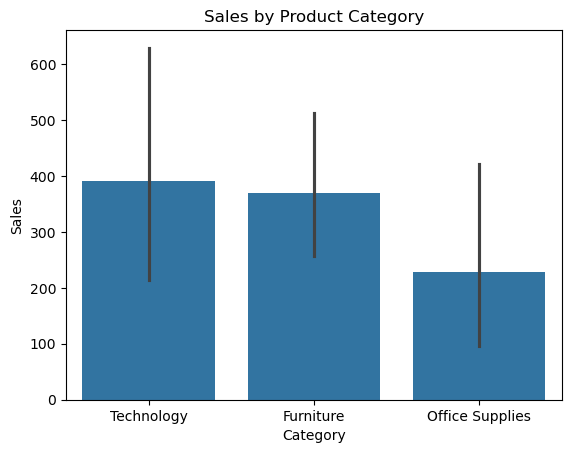

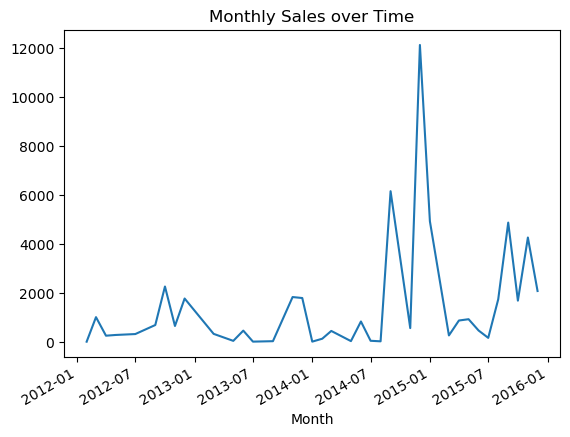

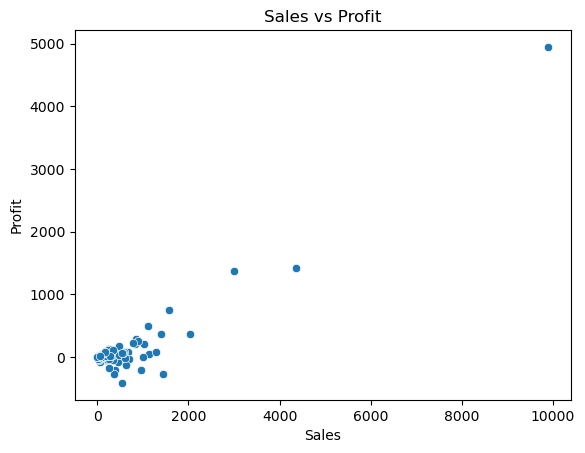

Text(0.5, 1.0, 'Sales by Region and Product Category')

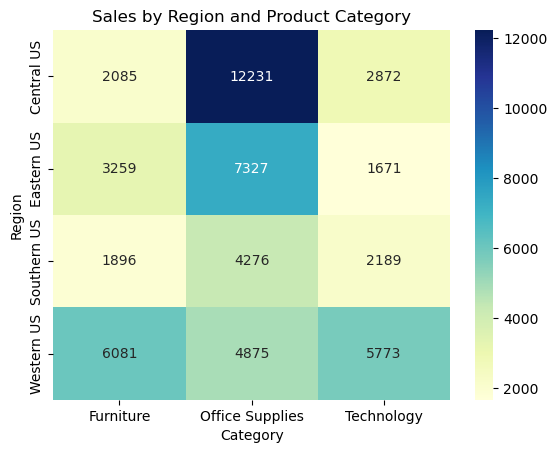

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline 
df = pd.read_csv('C:/Users/iqrab/OneDrive/Desktop/Data Analysis/Global_Superstore.csv')
# df.head()
# print (df.shape)
# df.info()
# df.describe()

# cleaning missing values
#print(df.isnull().sum())
df.dropna(inplace=True)   
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# calculate total sales and profit
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
print(f"Total Sales: {total_sales}, Total Profit: {total_profit}")

# identify top selling products (top 10)
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print (top_products)

# sales by region
sales_by_region = df.groupby('Region')['Sales'].sum()
print(sales_by_region)

# correlation between sales and profit
correlation = df['Sales'].corr(df['Profit'])
print(f"Correlation between sales and profit: {correlation}")

# bar chart of sales by product 
sns.barplot(x='Category', y='Sales', data = df)
plt.title('Sales by Product Category')
plt.show()

# line graph by creating new month column
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp() # ensures index is in datetime format to plot
monthly_sales.plot(kind = 'line')
plt.title('Monthly Sales over Time')
plt.show()

# scatter plot for sales and profit
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Sales vs Profit')
plt.show()

# heatmap
# pivot table for sales by region and product category
pivot_table = df.pivot_table(values= 'Sales', index= 'Region', columns= 'Category', aggfunc='sum')
sns.heatmap(pivot_table, annot= True, fmt= '.0f', cmap = 'YlGnBu')
plt.title('Sales by Region and Product Category')

# Insights: 
# Sales data through the bar chart suggests that the technology category results in the most sales. 
# Technology also shows the most variability in sales as shown by the vertical line in the bar chart.
# The line graph shows an overall upawrd trend with a large upwards spike in 2015 as a potential outlier.
# Sales differ largly by region where leads in office supplies and Western US leads in furniture and technology